In [5]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    f1_score,
    recall_score,
    accuracy_score,
    precision_recall_curve,
    roc_curve,
)

# define project root
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

from config.paths import RESULTS_DIR, FIGURES_DIR, MODEL_RUNS_DIR


In [6]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    for bin_idx in range(n_bins):
        mask = bin_ids == bin_idx
        if np.any(mask):
            mean_prob = y_prob[mask].mean()
            mean_true = y_true[mask].mean()
            ece += mask.mean() * abs(mean_prob - mean_true)
    return ece

In [7]:
print("PROJECT_ROOT:", PROJECT_ROOT)
print("FIGURES_DIR:", FIGURES_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("MODEL_RUNS_DIR:", MODEL_RUNS_DIR)

logreg_run_dir = MODEL_RUNS_DIR / "logreg_overnight_2026_03_20_neg_log_loss_20260320_021633"
xgboost_run_dir = MODEL_RUNS_DIR / "xgboost_overnight_2026_03_20_neg_log_loss_20260320_020321"
random_forest_run_dir = MODEL_RUNS_DIR / "random_forest_overnight_2026_03_20_neg_log_loss_20260320_031327"

selected_run_dirs = [
    logreg_run_dir,
    random_forest_run_dir,
    xgboost_run_dir,
]

summary_files = [run_dir / "summary_metrics.csv" for run_dir in selected_run_dirs]
fold_files = [run_dir / "outer_fold_results.csv" for run_dir in selected_run_dirs]
oof_files = [run_dir / "oof_predictions.csv" for run_dir in selected_run_dirs]

print("summary_files:")
for f in summary_files:
    print("  ", f, "| exists:", f.exists())

print("\nfold_files:")
for f in fold_files:
    print("  ", f, "| exists:", f.exists())

print("\noof_files:")
for f in oof_files:
    print("  ", f, "| exists:", f.exists())

PROJECT_ROOT: c:\Users\john\Desktop\spring-2026-radon-risk-mapping
FIGURES_DIR: C:\Users\john\Desktop\spring-2026-radon-risk-mapping\figures
RESULTS_DIR: C:\Users\john\Desktop\spring-2026-radon-risk-mapping\results
MODEL_RUNS_DIR: C:\Users\john\Desktop\spring-2026-radon-risk-mapping\results\model_runs
summary_files:
   C:\Users\john\Desktop\spring-2026-radon-risk-mapping\results\model_runs\logreg_overnight_2026_03_20_neg_log_loss_20260320_021633\summary_metrics.csv | exists: True
   C:\Users\john\Desktop\spring-2026-radon-risk-mapping\results\model_runs\random_forest_overnight_2026_03_20_neg_log_loss_20260320_031327\summary_metrics.csv | exists: True
   C:\Users\john\Desktop\spring-2026-radon-risk-mapping\results\model_runs\xgboost_overnight_2026_03_20_neg_log_loss_20260320_020321\summary_metrics.csv | exists: True

fold_files:
   C:\Users\john\Desktop\spring-2026-radon-risk-mapping\results\model_runs\logreg_overnight_2026_03_20_neg_log_loss_20260320_021633\outer_fold_results.csv | exi

In [8]:
summary_dfs = []

for file in summary_files:
    df = pd.read_csv(file)
    df["run_dir"] = str(file.parent)
    summary_dfs.append(df)

all_summaries = pd.concat(summary_dfs, ignore_index=True)

print(all_summaries.columns.tolist())
all_summaries

['model_name', 'run_id', 'batch_tag', 'search_scoring', 'n_rows', 'positive_rate', 'n_outer_folds', 'oof_roc_auc', 'oof_aucpr', 'oof_log_loss', 'oof_brier', 'oof_ece', 'oof_f1', 'oof_recall', 'mean_fold_roc_auc', 'mean_fold_aucpr', 'mean_fold_log_loss', 'mean_fold_brier', 'mean_fold_ece', 'run_dir', 'classification_threshold', 'n_calibration_bins', 'oof_accuracy']


,model_name,run_id,batch_tag,search_scoring,n_rows,positive_rate,n_outer_folds,oof_roc_auc,oof_aucpr,oof_log_loss,...,oof_recall,mean_fold_roc_auc,mean_fold_aucpr,mean_fold_log_loss,mean_fold_brier,mean_fold_ece,run_dir,classification_threshold,n_calibration_bins,oof_accuracy
0,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,overnight_2026_03_20,neg_log_loss,10461,0.108594,5,0.628664,0.171108,0.333744,...,0.705106,0.635632,0.179859,0.333775,0.094777,0.026603,C:\Users\john\Desktop\spring-2026-radon-risk-m...,NaN,NaN,NaN
1,random_forest,random_forest_overnight_2026_03_20_neg_log_los...,overnight_2026_03_20,neg_log_loss,10461,0.108594,5,0.649478,0.183600,0.329423,...,0.669014,0.651206,0.189849,0.329490,0.093928,0.020740,C:\Users\john\Desktop\spring-2026-radon-risk-m...,0.1,10.0,0.559889
2,xgboost,xgboost_overnight_2026_03_20_neg_log_loss_2026...,overnight_2026_03_20,neg_log_loss,10461,0.108594,5,0.667299,0.191548,0.418317,...,0.799296,0.671378,0.195438,0.418517,0.131238,0.138147,C:\Users\john\Desktop\spring-2026-radon-risk-m...,0.1,10.0,0.441354


In [22]:
fold_dfs = []

for file in fold_files:
    df = pd.read_csv(file)
    df["run_dir"] = str(file.parent)
    fold_dfs.append(df)

all_folds_df = pd.concat(fold_dfs, ignore_index=True)

print(all_folds_df.columns.tolist())
all_folds_df

['model_name', 'run_id', 'outer_fold', 'n_train', 'n_val', 'train_positive_rate', 'val_positive_rate', 'roc_auc', 'aucpr', 'log_loss', 'brier', 'ece', 'f1', 'recall', 'accuracy', 'best_params_json', 'run_dir']


,model_name,run_id,outer_fold,n_train,n_val,train_positive_rate,val_positive_rate,roc_auc,aucpr,log_loss,brier,ece,f1,recall,accuracy,best_params_json,run_dir
0,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,0,8392,2069,0.112488,0.092798,0.590899,0.140598,0.307367,0.084030,0.031230,0.179795,0.546875,0.536974,"{""classifier__C"": 0.0010672476836323724, ""clas...",C:\Users\john\Desktop\spring-2026-radon-risk-m...
1,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,1,8326,2135,0.108816,0.107728,0.630261,0.174735,0.330943,0.094193,0.005815,0.230931,0.717391,0.485246,"{""classifier__C"": 0.007890004262668575, ""class...",C:\Users\john\Desktop\spring-2026-radon-risk-m...
2,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,2,8345,2116,0.101618,0.136106,0.646364,0.228346,0.389431,0.114711,0.039421,0.307974,0.583333,0.643195,"{""classifier__C"": 0.0036084925884026665, ""clas...",C:\Users\john\Desktop\spring-2026-radon-risk-m...
3,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,3,8418,2043,0.104300,0.126285,0.636188,0.193155,0.369851,0.108343,0.022073,0.258526,0.910853,0.340186,"{""classifier__C"": 0.004809461967501573, ""class...",C:\Users\john\Desktop\spring-2026-radon-risk-m...
4,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,4,8363,2098,0.115748,0.080076,0.674448,0.162463,0.271281,0.072607,0.034476,0.194677,0.761905,0.495234,"{""classifier__C"": 0.024004075943521632, ""class...",C:\Users\john\Desktop\spring-2026-radon-risk-m...
5,random_forest,random_forest_overnight_2026_03_20_neg_log_los...,0,8392,2069,0.112488,0.092798,0.612559,0.151377,0.303311,0.083249,0.018012,0.200000,0.588542,0.563074,"{""classifier__bootstrap"": true, ""classifier__c...",C:\Users\john\Desktop\spring-2026-radon-risk-m...
6,random_forest,random_forest_overnight_2026_03_20_neg_log_los...,1,8326,2135,0.108816,0.107728,0.665640,0.197432,0.324352,0.092590,0.008083,0.250435,0.626087,0.596253,"{""classifier__bootstrap"": true, ""classifier__c...",C:\Users\john\Desktop\spring-2026-radon-risk-m...
7,random_forest,random_forest_overnight_2026_03_20_neg_log_los...,2,8345,2116,0.101618,0.136106,0.681607,0.240562,0.381979,0.114158,0.035168,0.329114,0.631944,0.649338,"{""classifier__bootstrap"": true, ""classifier__c...",C:\Users\john\Desktop\spring-2026-radon-risk-m...
8,random_forest,random_forest_overnight_2026_03_20_neg_log_los...,3,8418,2043,0.104300,0.126285,0.617051,0.185415,0.369695,0.108054,0.009420,0.253051,0.763566,0.430739,"{""classifier__bootstrap"": true, ""classifier__c...",C:\Users\john\Desktop\spring-2026-radon-risk-m...
9,random_forest,random_forest_overnight_2026_03_20_neg_log_los...,4,8363,2098,0.115748,0.080076,0.679173,0.174460,0.268113,0.071591,0.033015,0.209992,0.738095,0.555291,"{""classifier__bootstrap"": true, ""classifier__c...",C:\Users\john\Desktop\spring-2026-radon-risk-m...


In [23]:
oof_dfs = []

for file in oof_files:
    df = pd.read_csv(file)
    df["run_dir"] = str(file.parent)
    oof_dfs.append(df)

all_oof_df = pd.concat(oof_dfs, ignore_index=True)

print(all_oof_df.columns.tolist())
all_oof_df

['model_name', 'run_id', 'row_index', 'cv_fold', 'y_true', 'oof_prob', 'oof_pred_01', 'FSA', 'concentration', 'run_dir', 'oof_pred_at_threshold']


,model_name,run_id,row_index,cv_fold,y_true,oof_prob,oof_pred_01,FSA,concentration,run_dir,oof_pred_at_threshold
0,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,0,0,0,0.110011,1.0,V8J,7.5,C:\Users\john\Desktop\spring-2026-radon-risk-m...,NaN
1,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,1,0,0,0.110011,1.0,V8J,7.5,C:\Users\john\Desktop\spring-2026-radon-risk-m...,NaN
2,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,2,0,0,0.110011,1.0,V8J,7.5,C:\Users\john\Desktop\spring-2026-radon-risk-m...,NaN
3,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,3,0,0,0.110011,1.0,V8J,7.5,C:\Users\john\Desktop\spring-2026-radon-risk-m...,NaN
4,logreg,logreg_overnight_2026_03_20_neg_log_loss_20260...,4,0,0,0.110011,1.0,V8J,7.5,C:\Users\john\Desktop\spring-2026-radon-risk-m...,NaN
...,...,...,...,...,...,...,...,...,...,...,...
31378,xgboost,xgboost_overnight_2026_03_20_neg_log_loss_2026...,10456,2,0,0.085366,NaN,A1A,7.5,C:\Users\john\Desktop\spring-2026-radon-risk-m...,0.0
31379,xgboost,xgboost_overnight_2026_03_20_neg_log_loss_2026...,10457,2,0,0.085366,NaN,A1A,18.0,C:\Users\john\Desktop\spring-2026-radon-risk-m...,0.0
31380,xgboost,xgboost_overnight_2026_03_20_neg_log_loss_2026...,10458,2,0,0.085366,NaN,A1A,23.0,C:\Users\john\Desktop\spring-2026-radon-risk-m...,0.0
31381,xgboost,xgboost_overnight_2026_03_20_neg_log_loss_2026...,10459,2,0,0.085366,NaN,A1A,40.0,C:\Users\john\Desktop\spring-2026-radon-risk-m...,0.0


In [24]:
all_oof_df.isna().sum().sort_values(ascending=False)

oof_pred_01              20922
oof_pred_at_threshold    10461
model_name                   0
row_index                    0
run_id                       0
y_true                       0
cv_fold                      0
oof_prob                     0
FSA                          0
concentration                0
run_dir                      0
dtype: int64

In [25]:
core_columns = ["model_name", "y_true", "oof_prob"]
all_oof_df[core_columns].isna().sum()

model_name    0
y_true        0
oof_prob      0
dtype: int64

In [11]:
comparison_df = all_summaries[[
    "model_name",
    "oof_roc_auc",
    "oof_aucpr",
    "oof_log_loss",
    "oof_brier",
    "oof_ece",
    "oof_f1",
    "oof_recall",
    "run_id",
]].copy()

comparison_df = comparison_df.sort_values(
    by=["oof_aucpr", "oof_log_loss"],
    ascending=[False, True]
)

comparison_df

,model_name,oof_roc_auc,oof_aucpr,oof_log_loss,oof_brier,oof_ece,oof_f1,oof_recall,run_id
2,xgboost,0.667299,0.191548,0.418317,0.131160,0.138017,0.237076,0.799296,xgboost_overnight_2026_03_20_neg_log_loss_2026...
1,random_forest,0.649478,0.183600,0.329423,0.093914,0.001278,0.248204,0.669014,random_forest_overnight_2026_03_20_neg_log_los...
0,logreg,0.628664,0.171108,0.333744,0.094767,0.005469,0.234863,0.705106,logreg_overnight_2026_03_20_neg_log_loss_20260...


In [12]:
fold_summary = (
    all_folds_df
    .groupby("model_name")
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        mean_aucpr=("aucpr", "mean"),
        std_aucpr=("aucpr", "std"),
        mean_log_loss=("log_loss", "mean"),
        std_log_loss=("log_loss", "std"),
        mean_brier=("brier", "mean"),
        std_brier=("brier", "std"),
        mean_ece=("ece", "mean"),
        std_ece=("ece", "std"),
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_recall=("recall", "mean"),
        std_recall=("recall", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
    )
    .reset_index()
)

fold_summary

,model_name,mean_roc_auc,std_roc_auc,mean_aucpr,std_aucpr,mean_log_loss,std_log_loss,mean_brier,std_brier,mean_ece,std_ece,mean_accuracy,std_accuracy,mean_recall,std_recall,mean_f1,std_f1
0,logreg,0.635632,0.030216,0.179859,0.033159,0.333775,0.047460,0.094777,0.017239,0.026603,0.013232,0.500167,0.109147,0.704071,0.146261,0.234380,0.051398
1,random_forest,0.651206,0.033819,0.189849,0.033038,0.329490,0.047038,0.093928,0.017490,0.020740,0.012793,0.558939,0.080669,0.669647,0.076490,0.248518,0.050888
2,xgboost,0.671378,0.036619,0.195438,0.037080,0.418517,0.037629,0.131238,0.013297,0.138147,0.019927,0.440543,0.084371,0.799822,0.107047,0.236177,0.044193


In [13]:
CLASSIFICATION_THRESHOLD = 0.1

metric_rows = []

for model_name, df_model in all_oof_df.groupby("model_name"):
    y_true = df_model["y_true"].values
    y_prob = df_model["oof_prob"].values
    y_pred = (y_prob >= CLASSIFICATION_THRESHOLD).astype(int)

    metric_rows.append({
        "model_name": model_name,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "aucpr": average_precision_score(y_true, y_prob),
        "log_loss": log_loss(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "ece": expected_calibration_error(y_true, y_prob, n_bins=10),
        "accuracy_at_threshold": accuracy_score(y_true, y_pred),
        "recall_at_threshold": recall_score(y_true, y_pred, zero_division=0),
        "f1_at_threshold": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate": y_true.mean(),
        "predicted_positive_rate": y_pred.mean(),
    })

oof_metric_check_df = pd.DataFrame(metric_rows).sort_values(
    by=["aucpr", "log_loss"],
    ascending=[False, True]
)

oof_metric_check_df

,model_name,roc_auc,aucpr,log_loss,brier,ece,accuracy_at_threshold,recall_at_threshold,f1_at_threshold,positive_rate,predicted_positive_rate
2,xgboost,0.667299,0.191548,0.418317,0.131160,0.138017,0.441354,0.799296,0.237076,0.108594,0.623650
1,random_forest,0.649478,0.183600,0.329423,0.093914,0.001278,0.559889,0.669014,0.248204,0.108594,0.476819
0,logreg,0.628664,0.171108,0.333744,0.094767,0.005469,0.501099,0.705106,0.234863,0.108594,0.543447


In [14]:
final_comparison_df = oof_metric_check_df.merge(
    fold_summary,
    on="model_name",
    how="left"
)

final_comparison_df[[
    "model_name",
    "aucpr",
    "roc_auc",
    "log_loss",
    "brier",
    "ece",
    "recall_at_threshold",
    "f1_at_threshold",
    "mean_aucpr",
    "std_aucpr",
    "mean_log_loss",
    "std_log_loss",
]]

,model_name,aucpr,roc_auc,log_loss,brier,ece,recall_at_threshold,f1_at_threshold,mean_aucpr,std_aucpr,mean_log_loss,std_log_loss
0,xgboost,0.191548,0.667299,0.418317,0.131160,0.138017,0.799296,0.237076,0.195438,0.037080,0.418517,0.037629
1,random_forest,0.183600,0.649478,0.329423,0.093914,0.001278,0.669014,0.248204,0.189849,0.033038,0.329490,0.047038
2,logreg,0.171108,0.628664,0.333744,0.094767,0.005469,0.705106,0.234863,0.179859,0.033159,0.333775,0.047460


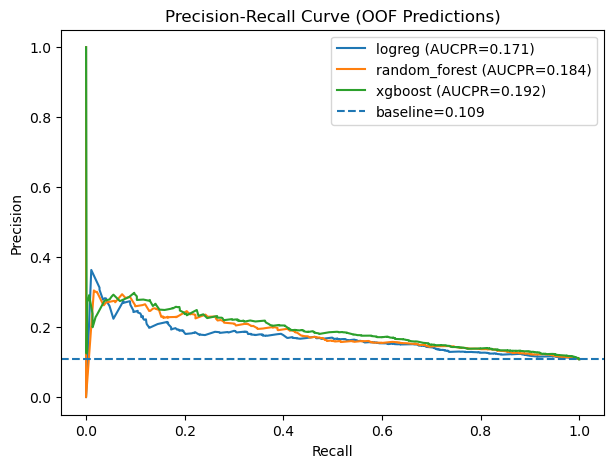

In [26]:
plt.figure(figsize=(7, 5))

for model_name, df_model in all_oof_df.groupby("model_name"):
    precision, recall, _ = precision_recall_curve(
        df_model["y_true"],
        df_model["oof_prob"]
    )
    aucpr = average_precision_score(df_model["y_true"], df_model["oof_prob"])
    plt.plot(recall, precision, label=f"{model_name} (AUCPR={aucpr:.3f})")

baseline_prevalence = (
    all_oof_df.loc[all_oof_df["model_name"] == "logreg", "y_true"].mean()
)
plt.axhline(baseline_prevalence, linestyle="--", label=f"baseline={baseline_prevalence:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (OOF Predictions)")
plt.legend()
plt.show()

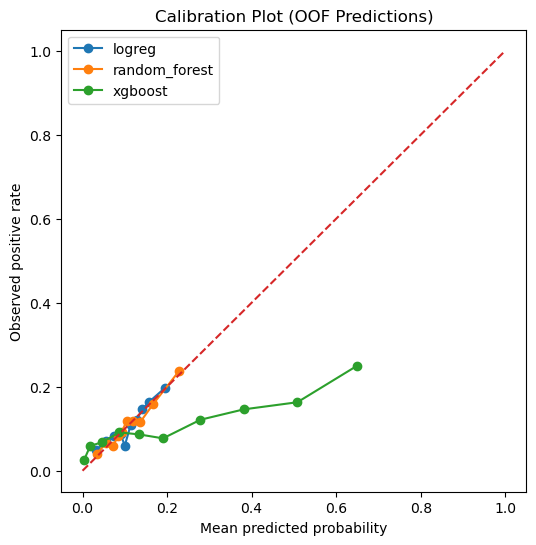

In [16]:
def calibration_table(y_true, y_prob, n_bins=10):
    df = pd.DataFrame({"y_true": y_true, "y_prob": y_prob})
    df["bin"] = pd.qcut(df["y_prob"], q=n_bins, duplicates="drop")
    grouped = df.groupby("bin", observed=False).agg(
        mean_prob=("y_prob", "mean"),
        frac_positive=("y_true", "mean"),
        count=("y_true", "size")
    ).reset_index()
    return grouped

plt.figure(figsize=(6, 6))

for model_name, df_model in all_oof_df.groupby("model_name"):
    cal_df = calibration_table(df_model["y_true"], df_model["oof_prob"], n_bins=10)
    plt.plot(cal_df["mean_prob"], cal_df["frac_positive"], marker="o", label=model_name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Calibration Plot (OOF Predictions)")
plt.legend()
plt.show()

In [17]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.30]

threshold_rows = []

for model_name, df_model in all_oof_df.groupby("model_name"):
    y_true = df_model["y_true"].values
    y_prob = df_model["oof_prob"].values

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)

        threshold_rows.append({
            "model_name": model_name,
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "predicted_positive_rate": y_pred.mean(),
        })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,model_name,threshold,accuracy,recall,f1,predicted_positive_rate
0,logreg,0.05,0.209445,0.952465,0.207399,0.888825
1,logreg,0.10,0.501099,0.705106,0.234863,0.543447
2,logreg,0.15,0.774209,0.323063,0.237080,0.187363
3,logreg,0.20,0.870184,0.095951,0.138325,0.042061
4,logreg,0.30,0.891215,0.000000,0.000000,0.000191
5,random_forest,0.05,0.215371,0.954225,0.208944,0.883281
6,random_forest,0.10,0.559889,0.669014,0.248204,0.476819
7,random_forest,0.15,0.770481,0.364437,0.256426,0.200076
8,random_forest,0.20,0.849441,0.161972,0.189398,0.077144
9,random_forest,0.30,0.891406,0.000000,0.000000,0.000000


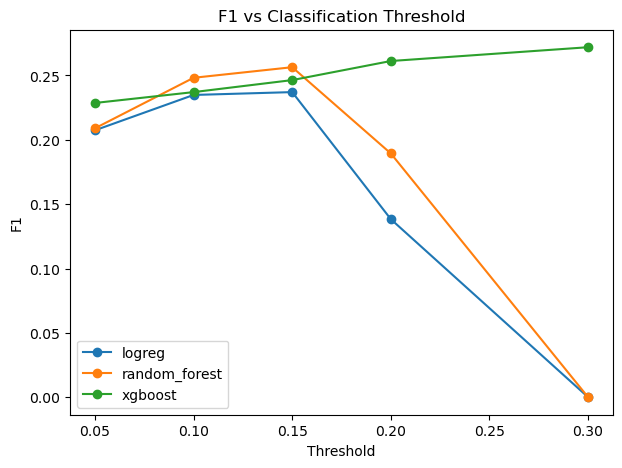

In [27]:
threshold_plot_df = threshold_df.copy()

plt.figure(figsize=(7, 5))
for model_name, df_model in threshold_plot_df.groupby("model_name"):
    plt.plot(df_model["threshold"], df_model["f1"], marker="o", label=model_name)

plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("F1 vs Classification Threshold")
plt.legend()
plt.show()

In [18]:
threshold_df.pivot(index="threshold", columns="model_name", values="recall")

model_name,logreg,random_forest,xgboost
threshold,,,
0.05,0.952465,0.954225,0.895246
0.10,0.705106,0.669014,0.799296
0.15,0.323063,0.364437,0.717430
0.20,0.095951,0.161972,0.652289
0.30,0.000000,0.000000,0.534331


In [19]:
threshold_df.pivot(index="threshold", columns="model_name", values="f1")

model_name,logreg,random_forest,xgboost
threshold,,,
0.05,0.207399,0.208944,0.228642
0.10,0.234863,0.248204,0.237076
0.15,0.237080,0.256426,0.246410
0.20,0.138325,0.189398,0.261237
0.30,0.000000,0.000000,0.271953


In [20]:
all_folds_df[["model_name", "outer_fold", "best_params_json"]]

,model_name,outer_fold,best_params_json
0,logreg,0,"{""classifier__C"": 0.0010672476836323724, ""clas..."
1,logreg,1,"{""classifier__C"": 0.007890004262668575, ""class..."
2,logreg,2,"{""classifier__C"": 0.0036084925884026665, ""clas..."
3,logreg,3,"{""classifier__C"": 0.004809461967501573, ""class..."
4,logreg,4,"{""classifier__C"": 0.024004075943521632, ""class..."
5,random_forest,0,"{""classifier__bootstrap"": true, ""classifier__c..."
6,random_forest,1,"{""classifier__bootstrap"": true, ""classifier__c..."
7,random_forest,2,"{""classifier__bootstrap"": true, ""classifier__c..."
8,random_forest,3,"{""classifier__bootstrap"": true, ""classifier__c..."
9,random_forest,4,"{""classifier__bootstrap"": true, ""classifier__c..."


In [21]:
for _, row in all_folds_df.iterrows():
    print(row["model_name"], "| fold", row["outer_fold"])
    print(json.loads(row["best_params_json"]))
    print()

logreg | fold 0
{'classifier__C': 0.0010672476836323724, 'classifier__class_weight': None, 'classifier__penalty': 'l2'}

logreg | fold 1
{'classifier__C': 0.007890004262668575, 'classifier__class_weight': None, 'classifier__penalty': 'l1'}

logreg | fold 2
{'classifier__C': 0.0036084925884026665, 'classifier__class_weight': None, 'classifier__penalty': 'l2'}

logreg | fold 3
{'classifier__C': 0.004809461967501573, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.5, 'classifier__penalty': 'elasticnet'}

logreg | fold 4
{'classifier__C': 0.024004075943521632, 'classifier__class_weight': None, 'classifier__penalty': 'l1'}

random_forest | fold 0
{'classifier__bootstrap': True, 'classifier__class_weight': None, 'classifier__max_depth': 15, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 7, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 884}

random_forest | fold 1
{'classifier__bootstrap': True, 'classifier__class_weight': None, 'classifier__

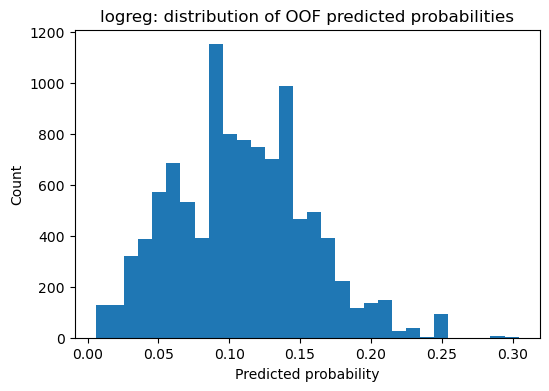

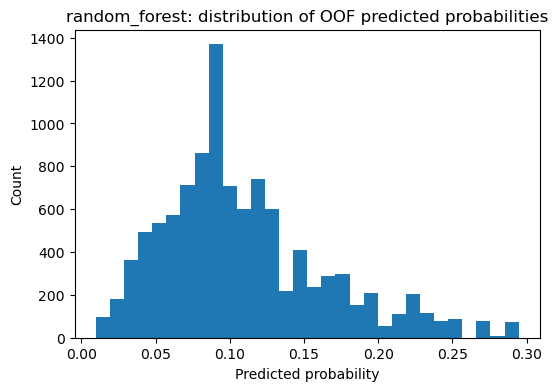

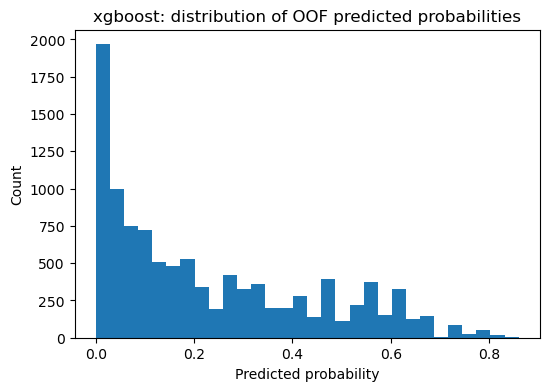

In [28]:
for model_name, df_model in all_oof_df.groupby("model_name"):
    plt.figure(figsize=(6, 4))
    plt.hist(df_model["oof_prob"], bins=30)
    plt.title(f"{model_name}: distribution of OOF predicted probabilities")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.show()

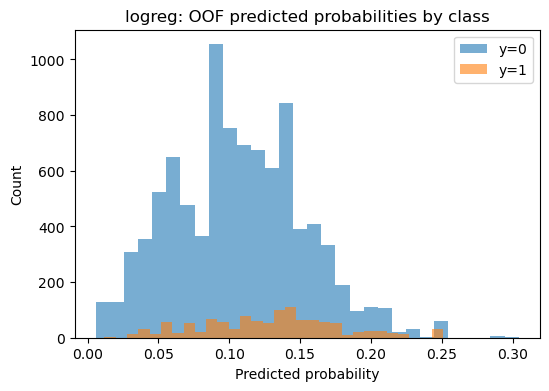

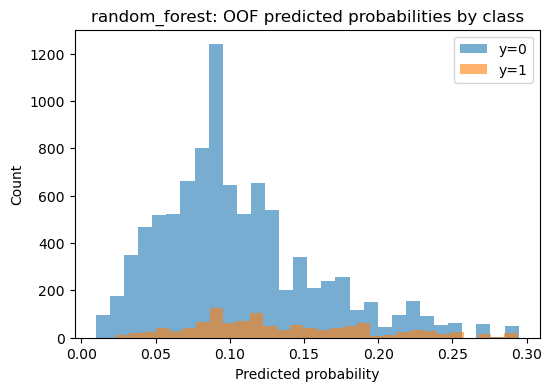

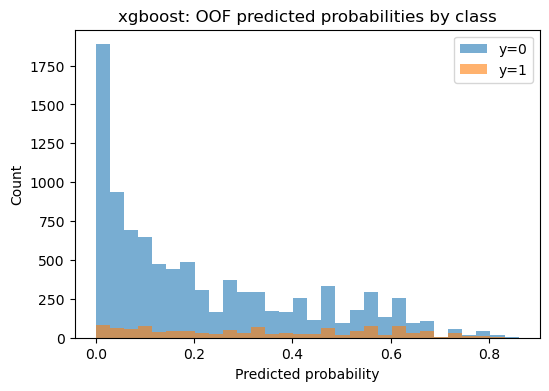

In [29]:
for model_name, df_model in all_oof_df.groupby("model_name"):
    plt.figure(figsize=(6, 4))
    plt.hist(df_model.loc[df_model["y_true"] == 0, "oof_prob"], bins=30, alpha=0.6, label="y=0")
    plt.hist(df_model.loc[df_model["y_true"] == 1, "oof_prob"], bins=30, alpha=0.6, label="y=1")
    plt.title(f"{model_name}: OOF predicted probabilities by class")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.legend()
    plt.show()